In [3]:
import pandas as pd

df = pd.read_csv("telco_clean_unique.csv")

# Keeping a copy of IDs
customer_ids = df['customerID']

# Dropping ID from features
df = df.drop(columns=['customerID'])

In [4]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Tenure group
bins = [0, 12, 24, 48, 72]
labels = ['0-12', '13-24', '25-48', '49-72']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

# High monthly charge flag
df['HighMonthly'] = (df['MonthlyCharges'] > 80).astype(int)

In [6]:
#Encoding target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
#Separating features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

In [7]:
#One hot encode categoricals
X = pd.get_dummies(X, drop_first=True)

In [28]:
#Training test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, cust_train, cust_test = train_test_split(
    X,
    y,
    customer_ids,
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [29]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train, y_train)

from sklearn.metrics import classification_report, roc_auc_score

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

AUC: 0.8424345759384122


In [30]:
#Getting coeffecient with feature names
import numpy as np

feature_names = X_train.columns
coefs = log_reg.coef_[0]  # or pipe.named_steps['log_reg'].coef_[0] if using pipeline

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs
})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df.sort_values('abs_coef', ascending=False).head(20)

,feature,coef,abs_coef
26,Contract_Two year,-1.422900,1.422900
11,InternetService_Fiber optic,1.287681,1.287681
25,Contract_One year,-0.704850,0.704850
33,tenure_group_49-72,0.558633,0.558633
22,StreamingTV_Yes,0.432372,0.432372
24,StreamingMovies_Yes,0.431304,0.431304
10,MultipleLines_Yes,0.424529,0.424529
27,PaperlessBilling_Yes,0.382220,0.382220
29,PaymentMethod_Electronic check,0.381315,0.381315
31,tenure_group_13-24,-0.323179,0.323179


In [31]:
#Trying a tree based model, random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("RF AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409

RF AUC: 0.8255728641917901


In [32]:
#Feature importance from random forest
fi = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(20)
print(fi)

                           feature  importance
3                     TotalCharges    0.163793
1                           tenure    0.149322
2                   MonthlyCharges    0.143231
26               Contract_Two year    0.049595
11     InternetService_Fiber optic    0.040700
29  PaymentMethod_Electronic check    0.036447
25               Contract_One year    0.026704
14              OnlineSecurity_Yes    0.026119
5                      gender_Male    0.025305
20                 TechSupport_Yes    0.025064
27            PaperlessBilling_Yes    0.024314
33              tenure_group_49-72    0.023656
6                      Partner_Yes    0.021442
16                OnlineBackup_Yes    0.020390
7                   Dependents_Yes    0.019077
10               MultipleLines_Yes    0.018065
0                    SeniorCitizen    0.017658
18            DeviceProtection_Yes    0.017296
24             StreamingMovies_Yes    0.015854
22                 StreamingTV_Yes    0.015144


# Key inferences
Model Performance
- Logistic regression, accuracy 0.80, churn recall 0.52, AUC 0.84.
- Random Forest, accuracy 0.79, churn recall 0.47, AUC 0.83.
- Linear decision boundary with one hot features already captures most signal
- Tree model doesnot add much, maybe slight overfit or redundant features.
So logistic regression is slightly better overall, especially on AUC and recall for churn class, which matters for retention.


Features that reduce churn (Negative coeffecients)
- Contract_Two year strong negative coefficient, long contracts sharply lower churn.
- Contract_One year also reduces churn, less strongly.
- tenure_group_13-24 negative, customers past first year churn less.
- OnlineSecurity_Yes and TechSupport_Yes negative, value added services keep customers.

Features that increase churn (Positive coeffeients)
- InternetService_Fiber optic large positive, fiber customers more likely to churn, possibly due to higher expectations or pricing.
- tenure_group_49-72 positive, some long tenure customers at risk, maybe due to contract end or competition.
- StreamingTV_Yes, StreamingMovies_Yes, MultipleLines_Yes, PaperlessBilling_Yes, PaymentMethod_Electronic check positive, richer service bundles and electronic check payment link to higher churn risk.

Story - churn is highest for month to month, fiber, high service bundle, electronic check customers, especially in early or very late tenure, and lowest for one or two year contracts with security and tech support addons.

In [33]:
#Tuning logistic regression 
log_reg_bal = LogisticRegression(
    max_iter=5000,
    class_weight='balanced'
)
log_reg_bal.fit(X_train, y_train)

y_pred_bal = log_reg_bal.predict(X_test)
y_proba_bal = log_reg_bal.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_bal))
print("Balanced AUC:", roc_auc_score(y_test, y_proba_bal))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Balanced AUC: 0.8421142369991474


# Key effect after tuning the logistic regression
- Churn class (1) recall increased from about 0.52 to 0.79.
- Churn precision dropped from about 0.65 to 0.50.
- Overall accuracy fell a bit to 0.74, but AUC stayed at 0.84.

Meaning, the balanced model catches many more churners but with more false alarms. This is good for retention scenarios where missing a churner is worse than flagging a few extra customers

# Recommended model for retention team: Balanced Logistic Regression

why: 
| Model             | AUC  | Churn Recall | Churn Precision | Use Case            |
| ----------------- | ---- | ------------ | --------------- | ------------------- |
| Logistic          | 0.84 | 0.52         | 0.65            | General ranking     |
| Balanced Logistic | 0.84 | 0.79         | 0.51            | Retention campaigns |
| Random Forest     | 0.83 | 0.47         | 0.65            | Feature importance  |

Business logic: 
- Retention goal is to contact customers at risk. High recall (0.79) catches most churners.
- Lower precision (0.51) means some loyal customers get retention offers, acceptable cost.
- AUC stable at 0.84 shows ranking quality preserved.

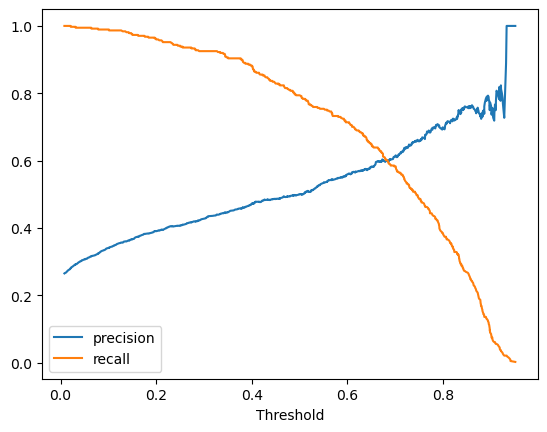

In [34]:
from sklearn.metrics import precision_recall_curve

y_scores = y_proba_bal  # from balanced model
prec, rec, thr = precision_recall_curve(y_test, y_scores)

import matplotlib.pyplot as plt
plt.plot(thr, prec[:-1], label='precision')
plt.plot(thr, rec[:-1], label='recall')
plt.xlabel('Threshold')
plt.legend()
plt.show()

In [35]:
threshold = 0.6
y_pred_custom = (y_scores >= threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_custom))
print(confusion_matrix(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1035
           1       0.56      0.71      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.78      0.78      1409

[[825 210]
 [107 267]]


# Inference at threshold 0.6 using balanced logistic:

- Model catches 71 percent of churners, 267 out of 374, good recall for retention.
- About 56 percent of flagged customers churn, so more than half of outreach is on true at risk users.
- Still we are missing 107 churners, and we contact 210 non churners unnecessarily, but this tradeoff is acceptable if retention offers are cheap compared to churn loss.

** Recomendation for the retention team**

Using the balanced logistic model with 0.6 churn probability thresold to target customers would catch 7 out of 10 churners while keeping more than half of outreach focused on truly at risk users, so prioritizing proactive offers for customers flagged by the model especially those on month to month contracts, fiber optics plans, electronic check payments, and high monthly charges.


In [37]:
telco_scores = X_test.copy()

telco_scores["customerID"] = cust_test.values
telco_scores['Churn_actual'] = y_test.values
telco_scores['Churn_prob'] = y_scores
telco_scores['Churn_flag'] = y_pred_custom

telco_scores.to_csv("telco_churn_scored.csv", index=False)